In [1]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def map_(v,x1,x2,y1,y2):
    ret = (v-x1)/(x2-x1) * (y2-y1) + y1
    return ret

In [3]:
#rebate
newR = {'r0':0.35, 'r1':0.37, 'r2':0.39, 's0':500, 's1':700, 'fee':15.0, 'v':0.40}
oldR = {'r0':0.315, 'r1':0.325, 'r2':0.335, 's0':400, 's1':465, 'fee':0.0, 'v':0.40}

In [4]:
spot_mini = 150
spot_maxi = 500
eqcp_mini = 250
eqcp_maxi = 750 #max 700 /actual 616
inc=5
risque=10
eqcp_nb= (eqcp_maxi-eqcp_mini)/inc
spot_nb = (spot_maxi-spot_mini)/inc
print(spot_nb,eqcp_nb)
# map()

70.0 100.0


In [5]:
eqcp_list = np.array([i for i in range(eqcp_mini,eqcp_maxi,inc)])
spot_list = np.array([i for i in range(spot_mini,spot_maxi,inc)])

In [6]:
def get_price(eqcp,spot):
    new_rebate = ( newR['r2'] if eqcp>newR['s1'] else newR['r1'] if eqcp>newR['s0'] else newR['r0'])
    var_spot2 = newR['v'] if (((1-new_rebate)*eqcp+risque)>(spot+newR['fee'])) else 0.
    new_price = eqcp * (1-new_rebate) * (1-var_spot2) + var_spot2*(spot+newR['fee'])
#    old_rebate = ( 0.28 if eqcp>=400 else 0.26 if eqcp >300 else 0.24)
    old_rebate = ( oldR['r2'] if eqcp>oldR['s1'] else oldR['r1'] if eqcp>oldR['s0'] else oldR['r0'])
    var_spot = oldR['v'] if (((1-old_rebate)*eqcp+risque)>(spot+oldR['fee'])) else 0.
    old_price = eqcp * (1-old_rebate) * (1-var_spot) + var_spot*(spot+oldR['fee'])
    return new_price,old_price,new_rebate, old_rebate,var_spot,var_spot2


In [7]:
df = pd.DataFrame(columns=eqcp_list)
for e in eqcp_list:
    pdS = pd.Series()
    for s in spot_list:
        n,o,_,_,_,_ = get_price(eqcp=e,spot=s)
        pdS[s] = int(o-n)
    df[e] = pdS
#df

In [8]:
risque = 10
eqcp = 505
spot = 318
n,o,nR,oR,vs,vs2 = get_price(eqcp=eqcp, spot=spot)
print(newR, oldR)
print(n,o,n-o,nR,oR,vs*100,vs2*100,'risque',risque)

{'r0': 0.35, 'r1': 0.37, 'r2': 0.39, 's0': 500, 's1': 700, 'fee': 15.0, 'v': 0.4} {'r0': 0.315, 'r1': 0.325, 'r2': 0.335, 's0': 400, 's1': 465, 'fee': 0.0, 'v': 0.4}
318.15 328.69500000000005 -10.545000000000073 0.37 0.335 40.0 0.0 risque 10


In [9]:
y_ = pd.Series()
for x_ in eqcp_list:
    vx= map_(x_*0.65,eqcp_mini,eqcp_maxi,0,eqcp_nb-1)
    vy = map_(vx,spot_nb-1, 0,spot_mini,spot_maxi)
    y_[vx] = vy
print(y_)


-17.3250    587.880435
-16.6815    584.616304
-16.0380    581.352174
-15.3945    578.088043
-14.7510    574.823913
               ...    
 43.8075    277.788043
 44.4510    274.523913
 45.0945    271.259783
 45.7380    267.995652
 46.3815    264.731522
Length: 100, dtype: float64


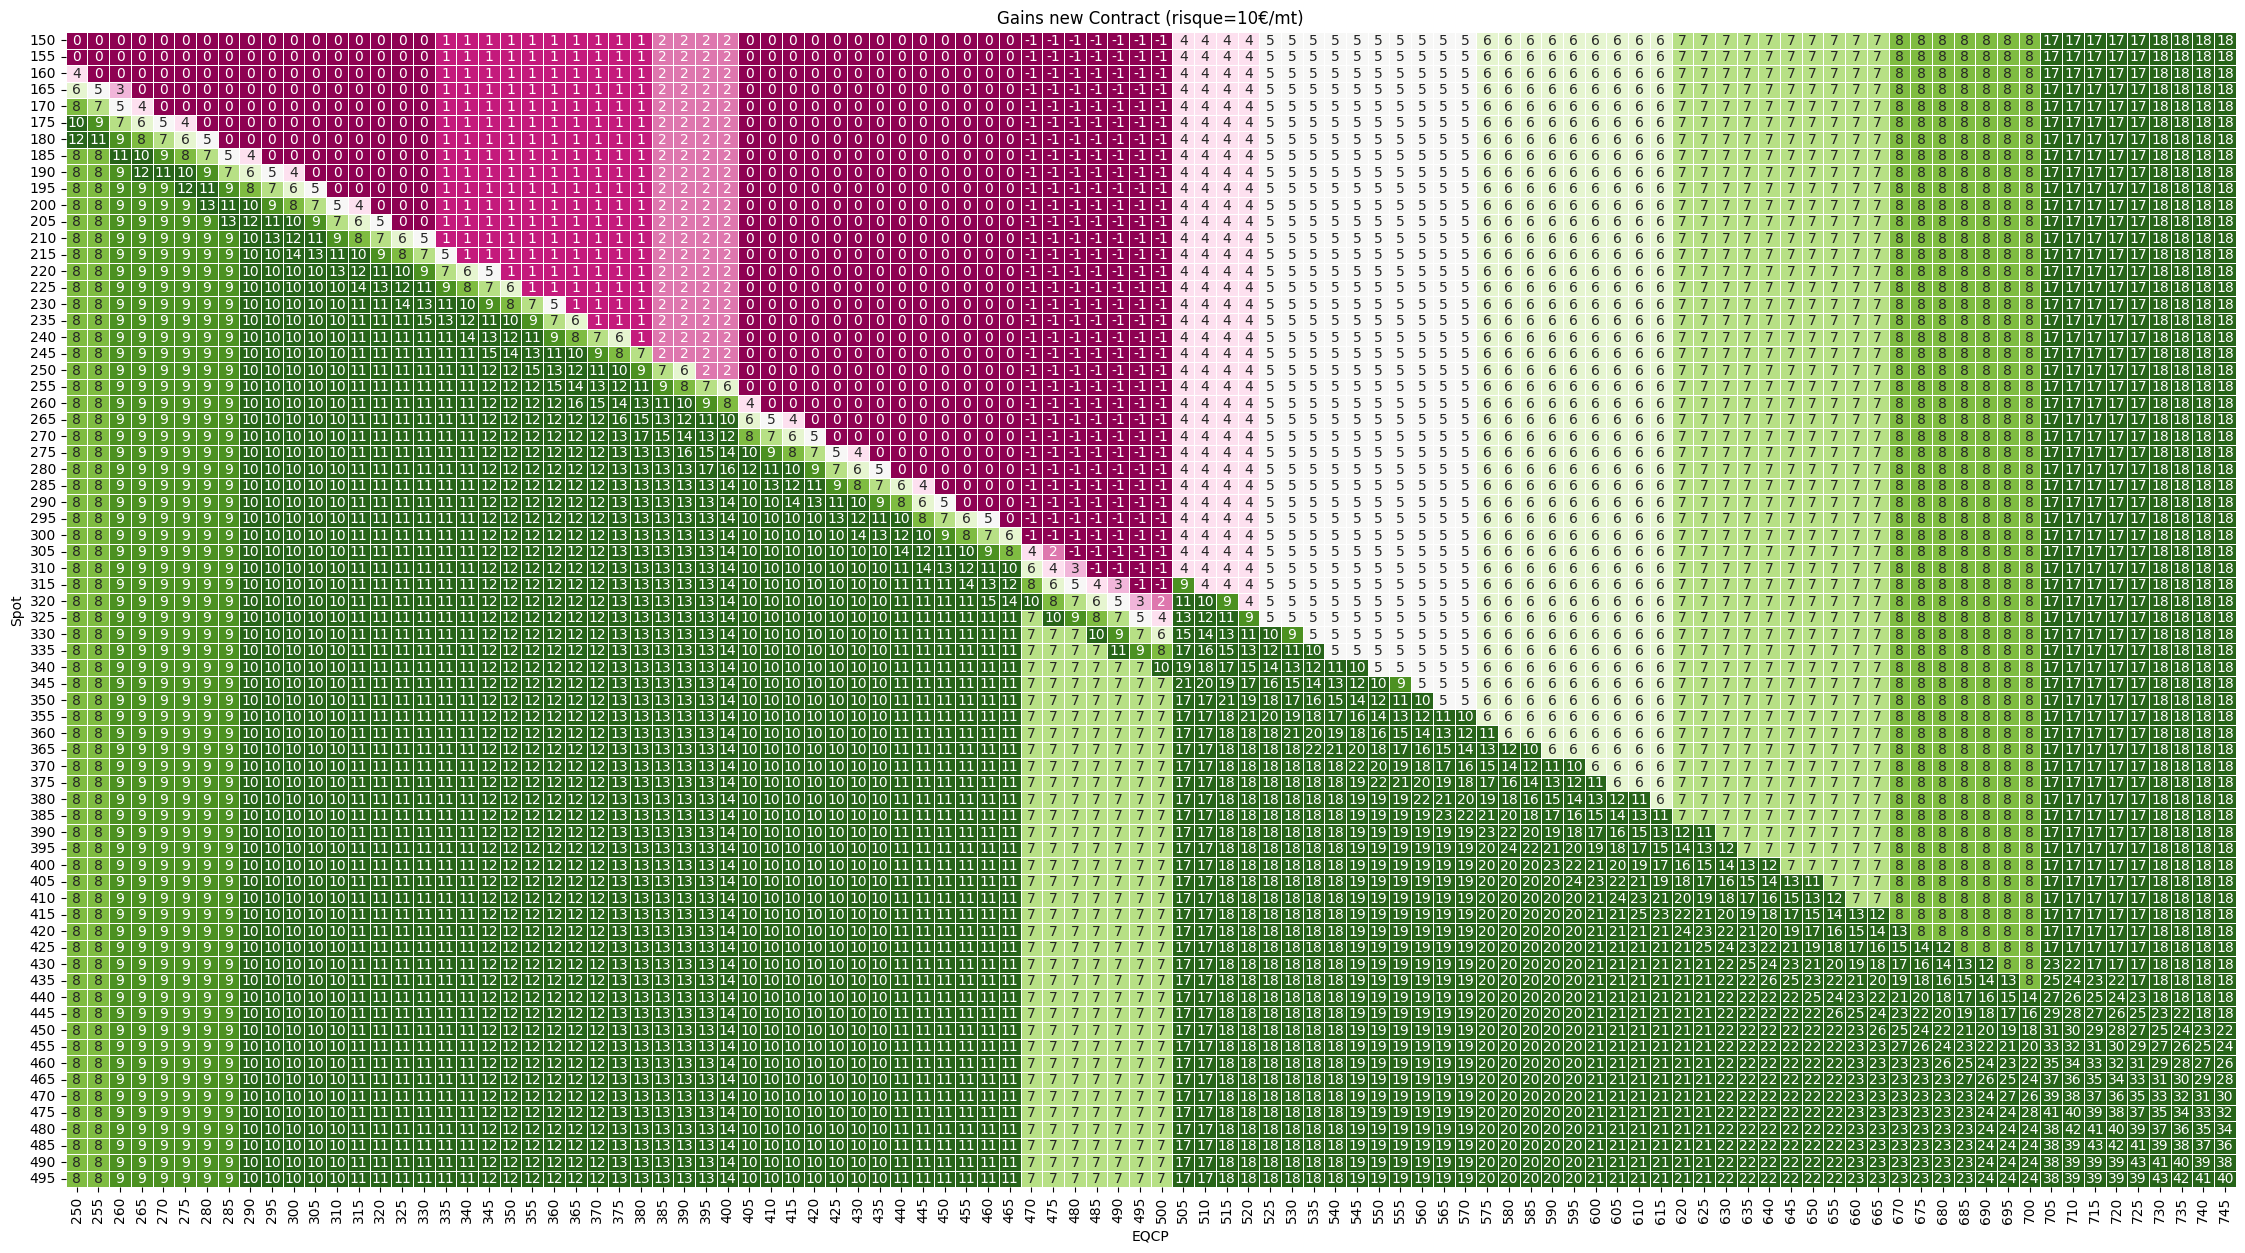

In [13]:

fig,ax = plt.subplots(figsize=(28,15))
# sns.set_palette("Paired")
plt.tick_params(bottom='on')
g = sns.heatmap(df.values,annot=True,xticklabels=eqcp_list, yticklabels=spot_list, linewidth=.5 ,cmap='PiYG', vmin=0, vmax=10,cbar=False);
# im = ax.imshow(df ,cmap='PiYG', vmin=-15, vmax=15, aspect='auto');
g.set_xlabel('EQCP');
g.set_ylabel('Spot');
g.set_title('Gains new Contract (risque={}€/mt)'.format(risque));
# ax2 = plt.twinx()
# x_ = (eqcp_list-eqcp_mini)/5
# y_ = (x_.max()-x_)*0.7
# sns.lineplot(x=x_, y=y_, linewidth=5, ax=ax2);
# ax.plot(eqcp_list*0.7, linewidth=50);
# ax2.axis('tight')


In [11]:
geyser = sns.load_dataset("geyser")
geyser

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long
...,...,...,...
267,4.117,81,long
268,2.150,46,short
269,4.417,90,long
270,1.817,46,short


In [12]:
fig = plt.figure(figsize=(28,15))
sns.set_palette("Paired")
graphe2 = sns.displot(data=df, x=df[200], y=df[350], kind='kde');


KeyError: 200

<Figure size 2800x1500 with 0 Axes>